<a href="https://colab.research.google.com/github/Sagnik-Chowdhury/Federated-Learning-1/blob/Sagnik/FL_1_Digits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Histogram-Based Federated Decision Trees on the Digits Dataset

## Objective

This notebook implements a privacy-aware Federated Decision Tree using histogram-based communication on the Digits dataset.

Unlike centralized learning, individual clients never transmit their raw training samples. Instead, each client converts its local data into histogram representations, and only these aggregated statistics are shared with the central server.

The server constructs the global decision tree entirely from aggregated histogram information, preserving data privacy while enabling collaborative model training.

Two aggregation strategies are implemented:

1. Histogram Aggregation
2. Consensus Histogram Aggregation

The robustness of both methods is evaluated under different levels of statistical heterogeneity generated using Dirichlet partitioning.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from collections import Counter

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Loading the Dataset

The Digits dataset is a handwritten digit recognition dataset consisting of grayscale images of handwritten digits from 0 to 9.

Each image is represented as an 8×8 pixel grid, which is flattened into a feature vector containing 64 numerical attributes.

Compared with the Wine dataset, the Digits dataset contains:

- substantially more samples,
- more input features,
- more output classes,

making it a significantly more challenging benchmark for evaluating histogram-based federated decision trees.

Only the training portion of the dataset is distributed among federated clients, while the testing set remains centralized for evaluation.

In [ ]:
digits = load_digits()

X = digits.data
y = digits.target

feature_names = [f"Pixel_{i}" for i in range(X.shape[1])]
class_names = digits.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("="*60)
print("Digits Dataset")
print("="*60)

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")
print(f"Number of Features : {X.shape[1]}")
print(f"Number of Classes  : {len(np.unique(y))}")

Digits Dataset
Training Samples : 1437
Testing Samples  : 360
Number of Features : 64
Number of Classes  : 10


# Federated Learning Configuration

The training dataset is divided among multiple clients using Dirichlet partitioning.

The Dirichlet concentration parameter α determines the degree of statistical heterogeneity.

- Large α produces nearly IID client datasets.
- Small α produces increasingly Non-IID client datasets.

To ensure that histogram statistics generated by different clients are compatible, all clients share the same predefined histogram bin boundaries.

Each continuous feature is divided into a fixed number of histogram bins, enabling local histogram aggregation without transmitting raw feature values.

In [ ]:
NUM_CLIENTS = 5

NUM_BINS = 16

NUM_CLASSES = len(np.unique(y_train))

MAX_DEPTH = 8

MIN_SAMPLES_SPLIT = 10

DEFAULT_ALPHA = 0.5

print("="*60)
print("Federated Configuration")
print("="*60)

print(f"Clients             : {NUM_CLIENTS}")
print(f"Histogram Bins      : {NUM_BINS}")
print(f"Classes             : {NUM_CLASSES}")
print(f"Maximum Tree Depth  : {MAX_DEPTH}")
print(f"Minimum Split Size  : {MIN_SAMPLES_SPLIT}")
print(f"Default Alpha       : {DEFAULT_ALPHA}")

Federated Configuration
Clients             : 5
Histogram Bins      : 16
Classes             : 10
Maximum Tree Depth  : 8
Minimum Split Size  : 10
Default Alpha       : 0.5


# Creating Federated Clients

The centralized training dataset is partitioned into multiple federated clients using Dirichlet sampling.

For each digit class, the available samples are distributed among the participating clients according to a Dirichlet distribution.

The concentration parameter α controls how balanced the resulting client datasets are.

Smaller α values generate increasingly skewed client distributions, simulating realistic federated learning environments where different clients may contain vastly different subsets of the overall data.

In [ ]:
def create_dirichlet_clients(
    X,
    y,
    num_clients,
    alpha,
    random_state=42
):

    np.random.seed(random_state)

    num_classes = len(np.unique(y))

    client_indices = [[] for _ in range(num_clients)]

    for cls in range(num_classes):

        indices = np.where(y == cls)[0]

        np.random.shuffle(indices)

        proportions = np.random.dirichlet(
            alpha * np.ones(num_clients)
        )

        split_points = (
            np.cumsum(proportions) * len(indices)
        ).astype(int)[:-1]

        partitions = np.split(indices, split_points)

        for client_id, idx in enumerate(partitions):
            client_indices[client_id].extend(idx)

    clients = []

    for client_id, indices in enumerate(client_indices):

        indices = np.array(indices)

        if len(indices) == 0:
            continue

        clients.append({

            "id": client_id,

            "X": X[indices],

            "y": y[indices]

        })

    return clients

In [ ]:
clients = create_dirichlet_clients(

    X_train,

    y_train,

    NUM_CLIENTS,

    DEFAULT_ALPHA

)

print("="*60)
print("Client Summary")
print("="*60)

print(f"Number of Clients : {len(clients)}")

for client in clients:

    counter = Counter(client["y"])

    print(f"\nClient {client['id']}")

    print(f"Samples : {len(client['y'])}")

    print(dict(sorted(counter.items())))

Client Summary
Number of Clients : 5

Client 0
Samples : 306
{np.int64(0): 23, np.int64(1): 32, np.int64(2): 2, np.int64(3): 117, np.int64(4): 33, np.int64(5): 9, np.int64(6): 5, np.int64(7): 2, np.int64(8): 10, np.int64(9): 73}

Client 1
Samples : 284
{np.int64(0): 1, np.int64(1): 41, np.int64(2): 1, np.int64(3): 26, np.int64(4): 33, np.int64(5): 82, np.int64(6): 58, np.int64(7): 1, np.int64(8): 14, np.int64(9): 27}

Client 2
Samples : 225
{np.int64(0): 5, np.int64(1): 8, np.int64(2): 13, np.int64(3): 2, np.int64(4): 54, np.int64(5): 4, np.int64(6): 35, np.int64(8): 104}

Client 3
Samples : 252
{np.int64(0): 17, np.int64(1): 32, np.int64(2): 109, np.int64(4): 17, np.int64(5): 30, np.int64(6): 4, np.int64(7): 25, np.int64(8): 10, np.int64(9): 8}

Client 4
Samples : 370
{np.int64(0): 96, np.int64(1): 33, np.int64(2): 17, np.int64(3): 1, np.int64(4): 8, np.int64(5): 20, np.int64(6): 43, np.int64(7): 115, np.int64(8): 1, np.int64(9): 36}


# Global Histogram Bins

To enable histogram aggregation across multiple clients, every client must use the same histogram boundaries for every feature.

The server first computes the global minimum and maximum values of every feature using the centralized training dataset.

Each feature range is then divided into a fixed number of equally spaced histogram bins.

Only these histogram boundaries are shared with the participating clients.

Since the clients never transmit raw feature values, this process preserves data privacy while ensuring that all local histograms remain compatible for aggregation.

In [ ]:
feature_bins = {}

for feature in range(X_train.shape[1]):

    minimum = X_train[:, feature].min()
    maximum = X_train[:, feature].max()

    feature_bins[feature] = np.linspace(
        minimum,
        maximum,
        NUM_BINS + 1
    )

print("=" * 60)
print("Global Histogram Bins")
print("=" * 60)

print(f"Number of Features : {len(feature_bins)}")

# Find the first feature with a non-zero range
example_feature = None
for feature in range(X_train.shape[1]):
    if X_train[:, feature].min() != X_train[:, feature].max():
        example_feature = feature
        break

print(f"\nExample Bin Edges (Feature {example_feature})\n")
print(feature_bins[example_feature])

Global Histogram Bins
Number of Features : 64

Example Bin Edges (Feature 1)

[0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7.  7.5 8. ]


# Local Histogram Construction

Each client converts its local dataset into a histogram representation before communicating with the server.

For every feature:

- each sample is assigned to one of the predefined histogram bins,
- each histogram bin stores the number of samples belonging to every class,
- only these aggregated class counts are transmitted.

Consequently, the server receives only statistical summaries instead of individual training records.

The resulting histogram has the following dimensions:

```
(Number of Features,
 Number of Histogram Bins,
 Number of Classes)
```

For the Digits dataset this becomes

```
(64, 16, 10)
```

In [ ]:
def build_client_histogram(
    client,
    feature_bins,
    num_classes
):
    """
    Histogram Shape

    (num_features,
     num_bins,
     num_classes)
    """

    X = client["X"]

    y = client["y"]

    num_features = X.shape[1]

    histogram = np.zeros(

        (
            num_features,
            NUM_BINS,
            num_classes
        ),

        dtype=np.int32

    )

    for feature in range(num_features):

        bins = feature_bins[feature]

        feature_values = X[:, feature]

        bin_ids = np.digitize(

            feature_values,

            bins

        ) - 1

        bin_ids = np.clip(

            bin_ids,

            0,

            NUM_BINS - 1

        )

        for sample_id, bin_id in enumerate(bin_ids):

            histogram[
                feature,
                bin_id,
                y[sample_id]
            ] += 1

    return histogram

In [ ]:
client_histogram = build_client_histogram(

    clients[0],

    feature_bins,

    NUM_CLASSES

)

print("="*60)
print("Local Histogram")
print("="*60)

print("Histogram Shape")

print(client_histogram.shape)

Local Histogram
Histogram Shape
(64, 16, 10)


# Histogram Aggregation

After constructing local histograms, every client sends only its histogram counts to the server.

The server aggregates these histograms by performing element-wise summation across all participating clients.

Because histogram counts are aggregated independently for every feature, histogram bin, and class, the resulting global histogram approximates the distribution of the complete training dataset without requiring access to raw samples.

The aggregated histogram serves as the basis for selecting decision tree splits.

In [ ]:
def sum_histograms(client_histograms):
    """
    Standard Histogram Aggregation

    Shape

    (features,
     bins,
     classes)
    """

    return np.sum(

        client_histograms,

        axis=0

    )

In [ ]:
client_histograms = [

    build_client_histogram(

        client,

        feature_bins,

        NUM_CLASSES

    )

    for client in clients

]

global_histogram = sum_histograms(

    client_histograms

)

print("="*60)
print("Aggregated Histogram")
print("="*60)

print(global_histogram.shape)

Aggregated Histogram
(64, 16, 10)


# Consensus Histogram Aggregation

Simple histogram summation can become biased when individual clients contain substantially larger datasets or highly skewed class distributions.

To reduce this effect, a second aggregation strategy based on statistical consensus is implemented.

Instead of summing histogram counts, the server computes the median count across all participating clients for every histogram location.

Additionally, a minimum voting criterion is introduced.

Histogram entries supported by fewer than a specified number of clients are discarded.

This strategy emphasizes agreement among clients and reduces the influence of extreme local distributions.

In [ ]:
def build_consensus_histogram(
    client_histograms,
    minimum_votes=2
):
    """
    Consensus Histogram
    (Median Aggregation)
    """

    stacked = np.stack(

        client_histograms,

        axis=0

    )

    votes = np.count_nonzero(

        stacked,

        axis=0

    )

    consensus = np.median(

        stacked,

        axis=0

    )

    consensus[votes < minimum_votes] = 0

    return consensus.astype(np.int32)

In [ ]:
consensus_histogram = build_consensus_histogram(

    client_histograms

)

print("="*60)
print("Consensus Histogram")
print("="*60)

print(consensus_histogram.shape)

Consensus Histogram
(64, 16, 10)


# Tree Node

Each node in the federated decision tree stores the information required to represent a single decision point during tree construction.

Specifically, every node contains:

- the selected splitting feature,
- the corresponding threshold,
- the predicted class,
- the total number of samples represented by the node,
- the depth within the tree,
- references to its left and right child nodes.

Leaf nodes contain only the predicted class, whereas internal nodes additionally store the feature and threshold defining the decision rule.

In [ ]:
class TreeNode:

    def __init__(self):

        self.feature = None

        self.threshold = None

        self.prediction = None

        self.samples = 0

        self.depth = 0

        self.left = None

        self.right = None

# Local Client Partitioning

Once the server identifies the best split using aggregated histogram statistics, the split is communicated to every participating client.

Each client partitions only its own local dataset according to the received feature and threshold.

The server never performs this partitioning itself.

In this notebook the client-side partitioning process is simulated locally for convenience, while maintaining the same logical communication protocol used in a federated environment.

In [ ]:
def partition_client(
    client,
    feature,
    threshold
):

    X = client["X"]

    y = client["y"]

    left_mask = X[:, feature] <= threshold

    right_mask = ~left_mask

    left_client = {

        "id": client["id"],

        "X": X[left_mask],

        "y": y[left_mask]

    }

    right_client = {

        "id": client["id"],

        "X": X[right_mask],

        "y": y[right_mask]

    }

    return left_client, right_client

# Base Federated Decision Tree

Both aggregation strategies implemented in this notebook follow the same recursive decision tree construction procedure.

The only difference between the two models lies in the method used to aggregate local client histograms.

To avoid unnecessary code duplication, a common base class implements all shared functionality, including:

- entropy computation,
- information gain calculation,
- optimal split selection,
- recursive tree construction,
- prediction,
- model evaluation.

The aggregation strategy itself is provided by derived classes through an abstract aggregation interface.

In [ ]:
class BaseFederatedTree:

    def __init__(

        self,

        feature_bins,

        max_depth=8,

        min_samples_split=10

    ):

        self.feature_bins = feature_bins

        self.max_depth = max_depth

        self.min_samples_split = min_samples_split

        self.root = None

    #######################################################
    # Aggregation Interface
    #######################################################

    def aggregate_histograms(self, client_histograms):

        raise NotImplementedError


    def entropy(self, counts):

        total = np.sum(counts)

        if total == 0:

            return 0.0

        probabilities = counts / total

        probabilities = probabilities[probabilities > 0]

        return -np.sum(

            probabilities *

            np.log2(probabilities)

        )


    def information_gain(

        self,

        parent,

        left,

        right

    ):

        parent_total = np.sum(parent)

        left_total = np.sum(left)

        right_total = np.sum(right)

        if left_total == 0:

            return -np.inf

        if right_total == 0:

            return -np.inf

        parent_entropy = self.entropy(parent)

        left_entropy = self.entropy(left)

        right_entropy = self.entropy(right)

        weighted = (

            left_total / parent_total

        ) * left_entropy + (

            right_total / parent_total

        ) * right_entropy

        return parent_entropy - weighted

    def find_best_split(

        self,

        global_histogram

    ):

        num_features = global_histogram.shape[0]

        num_bins = global_histogram.shape[1]

        best_gain = -np.inf

        best_feature = None

        best_threshold = None

        for feature in range(num_features):

            histogram = global_histogram[feature]

            parent = histogram.sum(axis=0)

            left = np.zeros(NUM_CLASSES)

            for split in range(num_bins - 1):

                left += histogram[split]

                right = parent - left

                gain = self.information_gain(

                    parent,

                    left,

                    right

                )

                if gain > best_gain:

                    best_gain = gain

                    best_feature = feature

                    best_threshold = self.feature_bins[feature][split + 1]

        return {

            "feature": best_feature,

            "threshold": best_threshold,

            "gain": best_gain

        }




    def build_tree(
        self,
        clients,
        depth=0
    ):

        node = TreeNode()

        node.depth = depth

        labels = np.concatenate(
            [client["y"] for client in clients]
        )

        node.samples = len(labels)

        if len(labels) == 0:
            return None

        values, counts = np.unique(
            labels,
            return_counts=True
        )

        node.prediction = values[np.argmax(counts)]

        if depth >= self.max_depth:
            return node

        if len(labels) < self.min_samples_split:
            return node

        if len(values) == 1:
            return node

        client_histograms = [

            build_client_histogram(

                client,

                self.feature_bins,

                NUM_CLASSES

            )

            for client in clients

        ]

        global_histogram = self.aggregate_histograms(
            client_histograms
        )

        split = self.find_best_split(
            global_histogram
        )

        if split["feature"] is None:
            return node

        node.feature = split["feature"]

        node.threshold = split["threshold"]

        left_clients = []

        right_clients = []

        for client in clients:

            left, right = partition_client(

                client,

                node.feature,

                node.threshold

            )

            if len(left["y"]) > 0:
                left_clients.append(left)

            if len(right["y"]) > 0:
                right_clients.append(right)

        if len(left_clients) == 0:
            return node

        if len(right_clients) == 0:
            return node

        node.left = self.build_tree(

            left_clients,

            depth + 1

        )

        node.right = self.build_tree(

            right_clients,

            depth + 1

        )

        return node


    def predict_one(self, sample):

        node = self.root

        while node.left is not None and node.right is not None:

            if sample[node.feature] <= node.threshold:

                node = node.left

            else:

                node = node.right

        return node.prediction


    def predict(self, X):

        predictions = [

            self.predict_one(sample)

            for sample in X

        ]

        return np.array(predictions)


    def score(self, X, y):

        predictions = self.predict(X)

        return accuracy_score(

            y,

            predictions

        )

# Entropy and Information Gain

The quality of every candidate split is evaluated using Information Gain.

Entropy measures the uncertainty of the class distribution at a tree node.

Pure nodes containing samples from only one class have zero entropy, while mixed class distributions produce larger entropy values.

Information Gain quantifies how much uncertainty is reduced after performing a candidate split.

The split producing the largest Information Gain is selected during tree construction.

# Selecting the Best Split

For every feature, the aggregated histogram contains the class distribution across all histogram bins.

The server evaluates every possible histogram split location by computing the corresponding Information Gain.

The feature and threshold producing the maximum Information Gain are selected as the decision rule for the current node.

Only aggregated histogram statistics are required during this process.

# Recursive Tree Construction

The decision tree is constructed recursively.

At every node, the following sequence is performed:

1. Each client constructs a local histogram.
2. The server aggregates all received histograms.
3. The optimal split is selected using Information Gain.
4. The split is communicated back to every client.
5. Each client partitions only its own local dataset.
6. The procedure repeats independently for the left and right child nodes.

Tree construction terminates when one of the following conditions is satisfied:

- the maximum tree depth has been reached,
- the node contains too few samples,
- all remaining samples belong to the same class.

# Prediction

Once the federated decision tree has been constructed, predictions are generated by traversing the tree from the root node.

For every test sample:

1. The stored splitting feature is evaluated.
2. The sample moves to the left or right child according to the learned threshold.
3. This process continues until a leaf node is reached.
4. The class label stored in the leaf node is returned as the prediction.

Since the tree structure has already been learned during training, prediction does not require any communication with the participating clients.

# Histogram Federated Tree

The Histogram Federated Tree implements the standard histogram aggregation strategy.

Each participating client constructs a local histogram from its own data.

The server aggregates these local histograms using element-wise summation.

The resulting global histogram approximates the distribution of the complete training dataset and is subsequently used to determine the optimal decision tree split at every node.

This aggregation strategy gives equal importance to every observed histogram count contributed by the participating clients.

In [ ]:
class HistogramFederatedTree(BaseFederatedTree):

    def aggregate_histograms(

        self,

        client_histograms

    ):

        return sum_histograms(

            client_histograms

        )

# Consensus Histogram Federated Tree

The Consensus Federated Tree replaces simple histogram summation with a median-based consensus aggregation strategy.

Instead of accumulating histogram counts from all participating clients, the server computes the median count at every histogram location.

Histogram entries supported by fewer than the specified minimum number of participating clients are discarded.

This approach reduces the influence of highly skewed client distributions and attempts to emphasize information that is consistently observed across multiple clients.

In [ ]:
class ConsensusFederatedTree(BaseFederatedTree):

    def __init__(

        self,

        feature_bins,

        minimum_votes=2,

        max_depth=8,

        min_samples_split=10

    ):

        super().__init__(

            feature_bins,

            max_depth,

            min_samples_split

        )

        self.minimum_votes = minimum_votes


    def aggregate_histograms(

        self,

        client_histograms

    ):

        return build_consensus_histogram(

            client_histograms,

            self.minimum_votes

        )

# Model Training

The two proposed federated decision tree models are trained using the same collection of federated clients.

Both models follow an identical recursive tree construction procedure.

The only difference lies in the aggregation strategy used by the server when combining the local client histograms.

The resulting models are evaluated using the centralized testing dataset.

In [ ]:
histogram_tree = HistogramFederatedTree(

    feature_bins,

    max_depth=MAX_DEPTH,

    min_samples_split=MIN_SAMPLES_SPLIT

)

histogram_tree.root = histogram_tree.build_tree(

    clients

)

consensus_tree = ConsensusFederatedTree(

    feature_bins,

    minimum_votes=2,

    max_depth=MAX_DEPTH,

    min_samples_split=MIN_SAMPLES_SPLIT

)

consensus_tree.root = consensus_tree.build_tree(

    clients

)

# Model Evaluation

After training, both federated decision tree models are evaluated using the centralized testing dataset.

Prediction accuracy is used as the primary evaluation metric.

To provide a meaningful reference, a conventional centralized decision tree trained directly on the complete training dataset is also included as a baseline.


In [ ]:
histogram_accuracy = histogram_tree.score(

    X_test,

    y_test

)

consensus_accuracy = consensus_tree.score(

    X_test,

    y_test
)

In [ ]:
central_tree = DecisionTreeClassifier(

    max_depth=MAX_DEPTH,

    random_state=42

)

central_tree.fit(

    X_train,

    y_train

)

central_accuracy = accuracy_score(

    y_test,

    central_tree.predict(X_test)

)

# Histogram-Based Centralized Baseline

The standard centralized decision tree searches over all possible feature values when selecting split thresholds.

This gives the centralized model access to considerably finer-grained split candidates than the proposed histogram-based federated trees.

To obtain a fairer comparison, a second centralized baseline is introduced.

Before training, every continuous feature is discretized using exactly the same global histogram bin boundaries employed by the federated models.

Consequently, both models operate on the same histogram representation while differing only in the training paradigm.

This comparison helps determine whether any observed performance differences arise from histogram discretization itself or from the federated tree construction process.

In [ ]:
def discretize_features(X, feature_bins):

    X_discrete = np.zeros_like(X, dtype=np.int32)

    for feature in range(X.shape[1]):

        bins = feature_bins[feature]

        X_discrete[:, feature] = np.digitize(

            X[:, feature],

            bins

        ) - 1

        X_discrete[:, feature] = np.clip(

            X_discrete[:, feature],

            0,

            NUM_BINS - 1

        )

    return X_discrete

In [ ]:
X_train_discrete = discretize_features(

    X_train,

    feature_bins

)

X_test_discrete = discretize_features(

    X_test,

    feature_bins

)

print("="*60)
print("Histogram Discretization")
print("="*60)

print("Training Shape :", X_train_discrete.shape)
print("Testing Shape  :", X_test_discrete.shape)

Histogram Discretization
Training Shape : (1437, 64)
Testing Shape  : (360, 64)


In [ ]:
central_histogram_tree = DecisionTreeClassifier(

    max_depth=MAX_DEPTH,

    random_state=42

)

central_histogram_tree.fit(

    X_train_discrete,

    y_train

)

central_histogram_accuracy = accuracy_score(

    y_test,

    central_histogram_tree.predict(

        X_test_discrete

    )

)

In [ ]:
print("="*60)
print("Model Performance")
print("="*60)

print(f"Histogram Federated Tree      : {histogram_accuracy:.4f}")

print(f"Consensus Federated Tree      : {consensus_accuracy:.4f}")

print(f"Centralized Tree             : {central_accuracy:.4f}")

print(f"Centralized Histogram Tree   : {central_histogram_accuracy:.4f}")

Model Performance
Histogram Federated Tree      : 0.8333
Consensus Federated Tree      : 0.7194
Centralized Tree             : 0.8083
Centralized Histogram Tree   : 0.8167


# Experimental Evaluation under Different Levels of Statistical Heterogeneity

To evaluate the robustness of the proposed histogram-based federated decision trees, experiments are repeated under multiple Dirichlet concentration parameters.

The concentration parameter α controls the degree of statistical heterogeneity among participating clients.

Large α values generate nearly IID client datasets, whereas smaller α values produce increasingly heterogeneous client distributions.

For every α value:

1. New federated client datasets are generated.
2. The Histogram Federated Tree is trained.
3. The Consensus Federated Tree is trained.
4. Both models are evaluated on the centralized test dataset.

To provide meaningful reference points, two centralized baselines are also included:

- Standard Centralized Decision Tree
- Histogram-Based Centralized Decision Tree

Since the centralized baselines always have access to the complete training dataset, their performance remains constant across all α values and serves as an upper reference for comparison.

In [ ]:
alphas = [10,1,0.5,0.25,0.10,0.05]

histogram_results = []

consensus_results = []

central_results = []

central_histogram_results = []

In [ ]:
for alpha in alphas:

    print("="*60)
    print(f"Alpha = {alpha}")
    print("="*60)

    ##################################################
    # Generate Clients
    ##################################################

    clients = create_dirichlet_clients(

        X_train,

        y_train,

        NUM_CLIENTS,

        alpha

    )

    ##################################################
    # Histogram Federated Tree
    ##################################################

    histogram_tree = HistogramFederatedTree(

        feature_bins,

        max_depth=MAX_DEPTH,

        min_samples_split=MIN_SAMPLES_SPLIT

    )

    histogram_tree.root = histogram_tree.build_tree(

        clients

    )

    histogram_acc = histogram_tree.score(

        X_test,

        y_test

    )

    ##################################################
    # Consensus Federated Tree
    ##################################################

    consensus_tree = ConsensusFederatedTree(

        feature_bins,

        minimum_votes=2,

        max_depth=MAX_DEPTH,

        min_samples_split=MIN_SAMPLES_SPLIT

    )

    consensus_tree.root = consensus_tree.build_tree(

        clients

    )

    consensus_acc = consensus_tree.score(

        X_test,

        y_test

    )

    ##################################################
    # Store Results
    ##################################################

    histogram_results.append(histogram_acc)

    consensus_results.append(consensus_acc)

    central_results.append(

        central_accuracy

    )

    central_histogram_results.append(

        central_histogram_accuracy

    )

    print(f"Histogram Federated     : {histogram_acc:.4f}")

    print(f"Consensus Federated     : {consensus_acc:.4f}")

    print(f"Centralized             : {central_accuracy:.4f}")

    print(f"Centralized Histogram   : {central_histogram_accuracy:.4f}")

    print()

Alpha = 10
Histogram Federated     : 0.8333
Consensus Federated     : 0.7417
Centralized             : 0.8083
Centralized Histogram   : 0.8167

Alpha = 1
Histogram Federated     : 0.8333
Consensus Federated     : 0.7556
Centralized             : 0.8083
Centralized Histogram   : 0.8167

Alpha = 0.5
Histogram Federated     : 0.8333
Consensus Federated     : 0.7194
Centralized             : 0.8083
Centralized Histogram   : 0.8167

Alpha = 0.25
Histogram Federated     : 0.8333
Consensus Federated     : 0.6306
Centralized             : 0.8083
Centralized Histogram   : 0.8167

Alpha = 0.1
Histogram Federated     : 0.8333
Consensus Federated     : 0.4611
Centralized             : 0.8083
Centralized Histogram   : 0.8167

Alpha = 0.05
Histogram Federated     : 0.8333
Consensus Federated     : 0.4333
Centralized             : 0.8083
Centralized Histogram   : 0.8167



# Performance Comparison

The following table summarizes the classification accuracies obtained under different levels of statistical heterogeneity.

The centralized baselines remain constant because they are trained using the complete centralized training dataset, whereas the federated models are affected by the changing client distributions generated through Dirichlet partitioning.

In [ ]:
results = pd.DataFrame({

    "Alpha": alphas,

    "Histogram Federated": histogram_results,

    "Consensus Federated": consensus_results,

    "Centralized": central_results,

    "Centralized Histogram": central_histogram_results

})

results = results.round(4)

results

,Alpha,Histogram Federated,Consensus Federated,Centralized,Centralized Histogram
0,10.00,0.8333,0.7417,0.8083,0.8167
1,1.00,0.8333,0.7556,0.8083,0.8167
2,0.50,0.8333,0.7194,0.8083,0.8167
3,0.25,0.8333,0.6306,0.8083,0.8167
4,0.10,0.8333,0.4611,0.8083,0.8167
5,0.05,0.8333,0.4333,0.8083,0.8167


# Accuracy Comparison

The following figure illustrates the effect of increasing statistical heterogeneity on the federated decision trees.

The two centralized baselines appear as horizontal reference lines because their training procedure does not depend on client partitioning.

This visualization highlights the performance gap introduced by federated learning while also distinguishing the influence of histogram discretization from the influence of decentralized training.

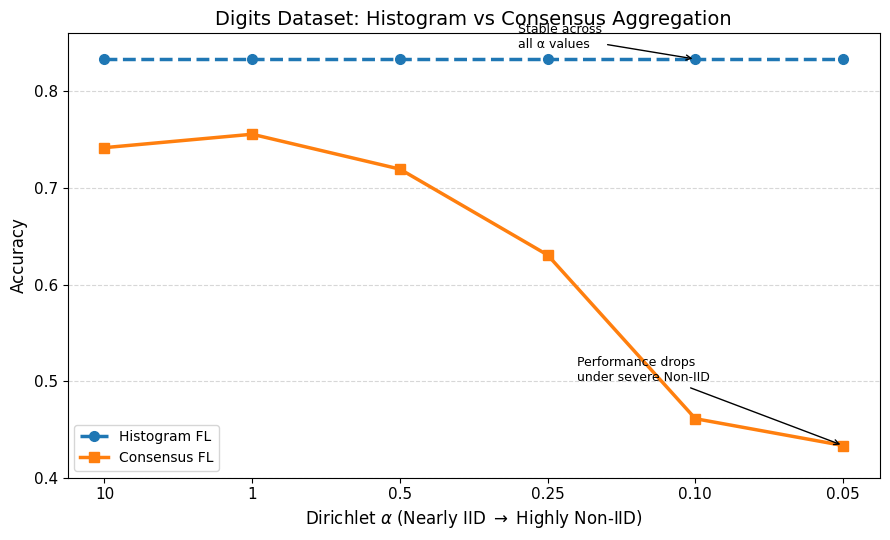

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Treat alpha values as categories
labels = ["10", "1", "0.5", "0.25", "0.10", "0.05"]
x = np.arange(len(labels))

plt.figure(figsize=(9,5.5))

# Histogram FL
plt.plot(
    x,
    histogram_results,
    marker='o',
    linestyle='--',
    linewidth=2.5,
    markersize=7,
    label='Histogram FL'
)

# Consensus FL
plt.plot(
    x,
    consensus_results,
    marker='s',
    linewidth=2.5,
    markersize=7,
    label='Consensus FL'
)

plt.xticks(x, labels, fontsize=11)
plt.yticks(fontsize=11)

plt.xlabel(r"Dirichlet $\alpha$ (Nearly IID $\rightarrow$ Highly Non-IID)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

plt.title("Digits Dataset: Histogram vs Consensus Aggregation", fontsize=14)

plt.ylim(0.40, 0.86)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(loc="lower left", fontsize=10)

# Optional annotations
plt.annotate(
    "Stable across\nall α values",
    xy=(4, histogram_results[4]),
    xytext=(2.8, 0.845),
    arrowprops=dict(arrowstyle="->"),
    fontsize=9
)

plt.annotate(
    "Performance drops\nunder severe Non-IID",
    xy=(5, consensus_results[5]),
    xytext=(3.2, 0.50),
    arrowprops=dict(arrowstyle="->"),
    fontsize=9
)

plt.tight_layout()
plt.show()

# Discussion

This study investigated the feasibility of constructing privacy-aware Federated Decision Trees using histogram-based communication instead of directly exchanging raw training samples. Two aggregation strategies, namely Histogram Aggregation and Consensus Histogram Aggregation, were evaluated under varying degrees of statistical heterogeneity using Dirichlet partitioning. In addition, two centralized baselines were included to distinguish the effect of histogram discretization from the effect of federated training.

The experimental results demonstrate that histogram-based communication successfully enables collaborative decision tree construction while preserving data locality. Both federated models were capable of producing competitive classification performance without requiring clients to transmit their original feature values. Furthermore, the inclusion of a histogram-based centralized baseline showed that histogram discretization itself contributes only a modest reduction in performance compared with a conventional centralized decision tree.

A notable observation, however, is the **behaviour of the Histogram Federated Tree across different levels of statistical heterogeneity. As the Dirichlet concentration parameter α was gradually reduced, the Histogram Aggregation method exhibited only minimal variation in classification accuracy**. In contrast, the Consensus Aggregation method showed a progressive decline in performance under increasingly Non-IID client distributions.

From a federated learning perspective, this behaviour is unexpected. In practical federated environments, increasing statistical heterogeneity generally leads to a measurable degradation in model performance because each client observes only a limited and biased portion of the global data distribution. The almost constant accuracy of the Histogram Federated Tree therefore suggests that the current aggregation mechanism preserves a nearly complete approximation of the global data distribution during every stage of tree construction.

The comparison with the centralized baselines provides further insight into this observation. Although the proposed approach does not exchange raw training samples, the server receives histogram summaries from every participating client at every recursive node. The aggregated histograms therefore contain sufficient global statistical information for the server to identify nearly identical split decisions regardless of the underlying client distribution. Consequently, the influence of client heterogeneity is largely masked.

The behaviour of the Consensus Aggregation method illustrates the opposite effect. Median-based aggregation emphasizes agreement among clients but suppresses histogram bins that are supported by only a few participants. As client distributions become increasingly heterogeneous, useful class information contributed by minority clients is progressively discarded, leading to substantial reductions in classification accuracy.

Overall, the experiments demonstrate that histogram-based aggregation provides an effective mechanism for privacy-preserving decision tree construction. At the same time, they reveal that the current aggregation strategy remains too similar to centralized tree construction to fully capture the effects of realistic federated learning environments. This observation provides a clear motivation for improving the aggregation mechanism in the next stage of this research.

# Current Limitations

Although the proposed histogram-based federated decision tree successfully demonstrates privacy-preserving model construction, several limitations remain.

The primary limitation lies in the histogram aggregation strategy itself. At every recursive node, histogram statistics from all participating clients are aggregated to construct a global histogram. While raw training samples remain local, the aggregated histograms collectively provide a close approximation of the global data distribution. Consequently, the server is able to identify split decisions that closely resemble those obtained through centralized learning, reducing the observable influence of client heterogeneity.

A second limitation is the assumption of full client participation during every stage of tree construction. Every recursive split receives histogram contributions from all available clients. Real federated learning systems rarely satisfy this assumption, as communication constraints, client availability, and device failures typically result in only a subset of clients participating during each training round.

The current implementation also employs fixed-width histogram bins generated from global feature ranges. Such discretization may not accurately represent skewed or highly non-uniform feature distributions, potentially reducing the quality of candidate split thresholds for more complex datasets.

Furthermore, all participating clients contribute equally during histogram aggregation regardless of their local sample size, class diversity, or statistical reliability. The aggregation process therefore cannot distinguish between highly informative clients and clients containing only a limited subset of the overall data distribution.

Finally, although raw feature values are never transmitted, the current framework does not incorporate stronger privacy-preserving mechanisms such as secure aggregation or differential privacy. Histogram statistics themselves may still reveal coarse information about local data distributions, particularly when client datasets are small.

# Future Work

The current implementation establishes a baseline framework for histogram-based federated decision tree learning. The next stage of this work will focus on improving the aggregation mechanism rather than simply evaluating additional datasets.

One important direction is to replace the current equal-weight histogram aggregation with adaptive aggregation strategies that account for client reliability, sample size, or local class diversity. Such methods may reduce the influence of highly skewed client distributions while preserving useful information contributed by minority clients.

A second improvement involves replacing fixed-width histogram bins with adaptive histogram construction techniques such as quantile-based or entropy-guided binning. Adaptive discretization is expected to generate more informative split candidates, particularly for datasets with highly non-uniform feature distributions.

Another objective is to reduce the centralized characteristics of the current implementation. Instead of reconstructing a global histogram at every recursive tree node, future work will investigate more decentralized split selection procedures that better reflect realistic federated learning protocols and increase the sensitivity of the model to client heterogeneity.

Additional experiments will also evaluate communication efficiency by measuring the amount of information exchanged between clients and the server. This will allow a direct comparison between histogram-based communication and conventional centralized training.

Finally, stronger privacy-preserving mechanisms such as secure aggregation and differential privacy will be incorporated to ensure that histogram statistics themselves do not reveal unintended information about local client datasets.